# Анализ лояльности пользователей Яндекс Афиши

**Автор:** Стеблев Д.И.  
**Дата:** 16.04.26

# Этапы выполнения проекта

**Цель и задачи**

**Цель:** Понять поведение пользователей,чтобы выяснить, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно .

**Задачи:**
1. Загрузить данные.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
4. Сформулировать выводы по проведённому анализу.

**Загрузка данных** 

Пишем SQL-запрос, выгружаем в датафрейм pandas необходимые данные. Используем следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки использовали библиотеку SQLAlchemy.

**Описание данных**

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `event_name` - название мероприятия в закодированном виде;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---

**Структура проекта**

1. Загрузка данных .
2. Предобработка данных.
3. Создание профиля пользователя
4. Исследовательский анализ данных.  
    4.1. Исследование признаков первого заказа и их связи с возвращением на платформу  
    4.2. Исследование поведения пользователей через показатели выручки и состава заказа  
    4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки  
    4.4. Корреляционный анализ количества покупок и признаков пользователя

5. Общий вывод и рекомендации

### 1 Загрузка данных 

In [1]:
import pandas as pd
from sqlalchemy import create_engine 
import seaborn as sns
import matplotlib.pyplot as plt
!pip install phik
from phik import phik_matrix

In [2]:
db_config = {'user': 'praktikum_student',
             'pwd': 'Sdf4$2;d-d30pp', 
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, 
             'db': 'data-analyst-afisha' 
             } 

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT 
  user_id,
  device_type_canonical,
  order_id,
  created_dt_msk as order_dt,
  created_ts_msk as order_ts,
  currency_code,
  revenue,
  tickets_count,
  created_dt_msk::date - LAG(created_dt_msk::date) over (partition by user_id ORDER BY created_dt_msk) as days_since_prev,
  p.event_id,
  event_name_code as event_name,
  event_type_main,
  service_name,
  region_name,
  city_name
FROM afisha.purchases as p
LEFT JOIN afisha.events as e on p.event_id=e.event_id
LEFT JOIN afisha.city as c on e.city_id=c.city_id
LEFT JOIN afisha.regions as r on c.region_id=r.region_id
WHERE (device_type_canonical='mobile' OR device_type_canonical='desktop')
    and (event_type_main != 'фильм')
ORDER BY user_id
'''

In [6]:
df = pd.read_sql_query(query, con=engine)

In [7]:
try:
    with engine.connect() as conn:
        print("Подключение к базе данных успешно установлено!")
except Exception as e:
    print(f"Ошибка подключения: {e}")

Подключение к базе данных успешно установлено!


In [8]:
df.head(5)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

В данных содержиться 290611 строка и 15 столбцов , пропуски в `days_since_prev`. Типы данных корректны.

---

###  2. Предобработка данных

В данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведем выручку к единой валюте — российскому рублю.

Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`.Значения в рублях представлено для 100 тенге.Результаты преобразования сохраним в новый столбец `revenue_rub`.

Загрузим его  `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`


In [10]:
tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [11]:
tickets_tenge_df['data'] = tickets_tenge_df['data'].astype('datetime64')

In [12]:
tickets_tenge_df['normal_curs'] = tickets_tenge_df['curs'] / 100 

In [13]:
tickets_tenge = tickets_tenge_df[['normal_curs','data','cdx']]

In [14]:
tickets_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   normal_curs  357 non-null    float64       
 1   data         357 non-null    datetime64[ns]
 2   cdx          357 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 8.5+ KB


In [15]:
df_marge = df.merge(tickets_tenge, left_on='order_dt', right_on='data', how='left')

In [16]:
def convert_currency_code(row):
    if row['currency_code'] == 'kzt':
        return row['revenue'] * row['normal_curs']
    else :
        return row['revenue']
        
df_marge['revenue_rub'] = df_marge.apply(convert_currency_code ,axis=1)      

Мнянем тип данных `data` datetime64 для коректного объеденения ,делим курс на 100 т.к. в данных используеться курс 
для 100 тенге, оставляем датасет `normal_curs`,`data`,`cdx` столбцы и обьеденяем с основным и создаем новый `df_marge` . Далее перемножаем `normal_curs`на `revenue` и создаем столбец `revenue_rub` c выручкой от заказа в рублях.


**Задача 2.2:** Проверим данные 


In [17]:
df_marge['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [18]:
df_marge['service_name'] = df_marge['service_name'].str.lower()
df_marge['service_name'].unique()

array(['край билетов', 'мой билет', 'за билетом!', 'лови билет!',
       'билеты без проблем', 'облачко', 'лучшие билеты', 'прачечная',
       'быстробилет', 'дом культуры', 'весь в билетах', 'билеты в руки',
       'тебе билет!', 'show_ticket', 'городской дом культуры', 'яблоко',
       'билет по телефону', 'выступления.ру', 'росбилет',
       'шоу начинается!', 'мир касс', 'восьмёрка', 'телебилет',
       'crazy ticket!', 'реестр', 'быстрый кассир', 'карандашру',
       'радио ticket', 'дырокол', 'вперёд!', 'кино билет', 'цвет и билет',
       'зе бест!', 'тех билет', 'лимоны', 'билеты в интернете'],
      dtype=object)

In [19]:
df_marge['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [20]:
df_marge['region_name'].nunique()

81

In [21]:
df_marge['city_name'].nunique()

352

In [22]:
df_marge.duplicated().sum()

0

Проверли уникальные значения в `device_type_canonical`,`service_name`,`event_type_main`,`region_name`,`city_name`.
Проверели отсутствие  дубликатов 

In [23]:
df_marge['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

<AxesSubplot:>

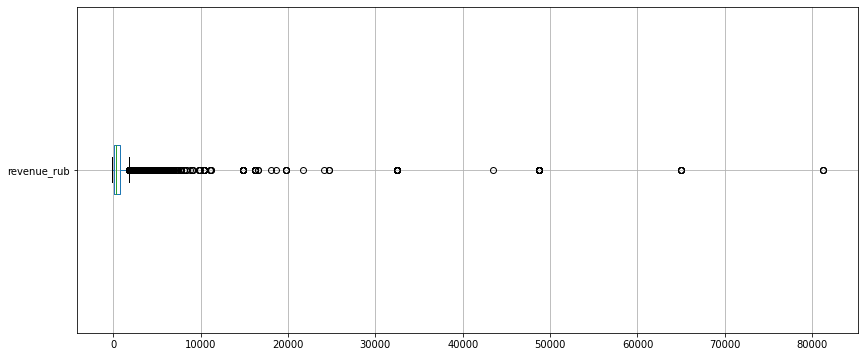

In [24]:
df_marge.boxplot(column='revenue_rub',figsize=(14,6),vert=False)

In [25]:
df_marge['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

<AxesSubplot:>

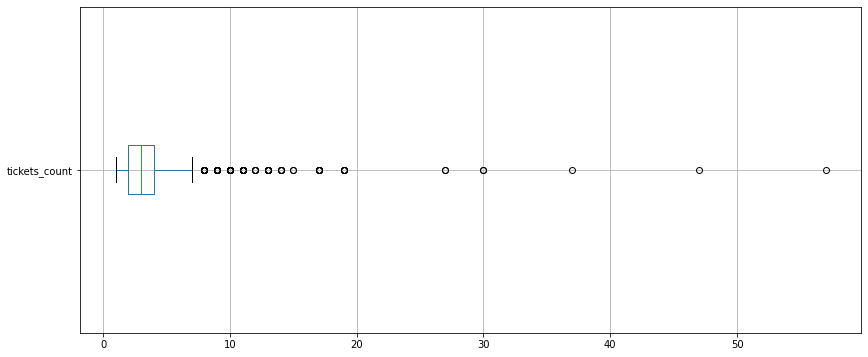

In [26]:
df_marge.boxplot(column='tickets_count',figsize=(14,6),vert=False)

In [27]:
lower = df_marge['tickets_count'].quantile(0.00)
upper = df_marge['tickets_count'].quantile(0.99)
df_filter = df_marge[(df_marge['tickets_count'] >= lower) & (df_marge['tickets_count'] <= upper)]
df_filter['tickets_count'].describe()

count    290423.000000
mean          2.749366
std           1.143899
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           6.000000
Name: tickets_count, dtype: float64

In [28]:
lower = df_marge['revenue_rub'].quantile(0.01)
upper = df_marge['revenue_rub'].quantile(0.99)
df_filter = df_marge[(df_marge['revenue_rub'] >= lower) & (df_marge['revenue_rub'] <= upper)]
df_filter['revenue_rub'].describe()

count    287405.000000
mean        518.719256
std         511.951842
min           0.000000
25%         112.600000
50%         344.830000
75%         788.900000
max        2628.421739
Name: revenue_rub, dtype: float64

В столбце `revenue_rub` присутствуют анаомално высокие значения и отрицательные .Стандартное отклонение 875,5 превышает 
среднее значение 555,6. Это признак высокой вариативности — данные распределены неравномерно.
Отфильтруем данные по 1 и 99 перцентилю этого будет достаточно чтобы отбросить отрицательные значения и 
анаомално высокие значения. Суммы заказов с нулевыми значениями оставим т.к. могли использовать промокоды,
скидкки,акции и сертификаты.

В столбце `tickets_count` присутствуют анаомално высокие значения.
Медиана 3 близка к среднему 2,75, что указывает на относительно симметричное распределение данных в центральной части.
Отфильтруем данные по 99 перцентилю этого будет достаточно чтобы отбросить анаомално высокие значения

После фильтрации создаем новый `df_filter` в котором содержиться 287 405 строк,что на 3 206 (около 1 %) меньше исходных данных.



### 3. Создание профиля пользователя

In [29]:
df_filter = df_filter.sort_values(by='order_ts')

Считаем агрегированные признаки

In [30]:
df_user = df_filter.groupby('user_id').agg(
    first_order_date=('order_dt', 'min'),
    last_order_date=('order_dt', 'max'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean')
).reset_index()

Груперуем по 'user_id' и берем первое значение даты группы с помщью .idxmin()

In [31]:
first_data = df_filter.groupby('user_id')['order_ts'].idxmin()

Создаем датасет с необходимыми столбцами где индекс first_data

In [32]:
first_data_order = df_filter.loc[first_data,['user_id','device_type_canonical','region_name','service_name','event_type_main']]

In [33]:
df_profile_user = df_user.merge(first_data_order, on='user_id',how='left')

Рсчитываем среднее время между заказами 

In [34]:
def avg_date(group):
    date = sorted(group['order_dt'])
    if len(date) < 2:
        return None
    else:
        interval = [(date[i] - date[i-1]).days for i in range(1,len(date))]
        return  sum(interval) / len(interval)
        
avg_date_user = df_filter.groupby('user_id').apply(avg_date).reset_index(name='avg_days')

In [35]:
df_profile_user = df_profile_user.merge(avg_date_user, on='user_id',how='left')

Создаем столбцы с бинарными признаким 2 и более заказа ,5 и более заказа.

In [36]:
df_profile_user['is_five'] = df_profile_user['total_orders'] >= 5
df_profile_user['is_two'] = (df_profile_user['total_orders'] >= 2) & (df_profile_user['total_orders'] < 5)

Нормализуем данные 

In [37]:
df_profile_user['avg_tickets'] = df_profile_user['avg_tickets'].astype('int8')

In [38]:
df_profile_user['avg_days'] = df_profile_user['avg_days'].fillna(0).astype('int8')

In [39]:
df_profile_user['avg_revenue_rub'] = round(df_profile_user['avg_revenue_rub'],2)

In [40]:
df_profile_user.head()

,user_id,first_order_date,last_order_date,total_orders,avg_revenue_rub,avg_tickets,device_type_canonical,region_name,service_name,event_type_main,avg_days,is_five,is_two
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.94,4,mobile,Каменевский регион,край билетов,театр,0,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.01,3,mobile,Каменевский регион,мой билет,выставки,75,False,True
2,000898990054619,2024-07-13,2024-10-23,3,767.21,2,mobile,Североярская область,лови билет!,другое,51,False,True
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.83,4,desktop,Каменевский регион,край билетов,театр,0,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.31,1,mobile,Поленовский край,лучшие билеты,театр,16,False,True


Создаем модели для прогнозирования возврата пользователей
на основе агрегированных признаков, описывающие поведение и профиль каждого пользователя.

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используем поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

Создаем два бинарных признака:

is_two — совершил ли пользователь 2 и более заказа;
is_five — совершил ли пользователь 5 и более заказов.

Объеденяем все в один датасет `profile_user` и нормализуеи данные.
В итоге в данных 21838 пользователь.

---

###  4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.



####  Исследование признаков первого заказа и их связи с возвращением на платформу


**4.1.1.** Изучаем распределение пользователей по признакам.

    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.


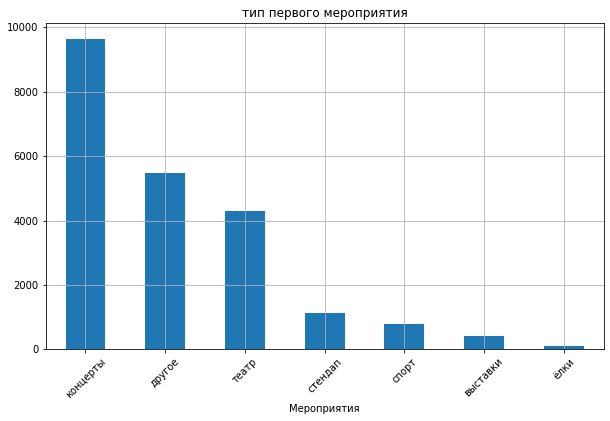

In [41]:
df_profile_user['event_type_main'].value_counts().plot(
                    kind='bar',
                    figsize=(10,6),
                    title='тип первого мероприятия',
                    xlabel='Мероприятия',
                    rot=45)
plt.grid()
plt.show()

In [42]:
df_profile_user['event_type_main'].value_counts()

концерты    9647
другое      5465
театр       4295
стендап     1118
спорт        801
выставки     417
ёлки          95
Name: event_type_main, dtype: int64

In [43]:
(df_profile_user['event_type_main'].value_counts(normalize=True)*100).round(2)

концерты    44.18
другое      25.03
театр       19.67
стендап      5.12
спорт        3.67
выставки     1.91
ёлки         0.44
Name: event_type_main, dtype: float64

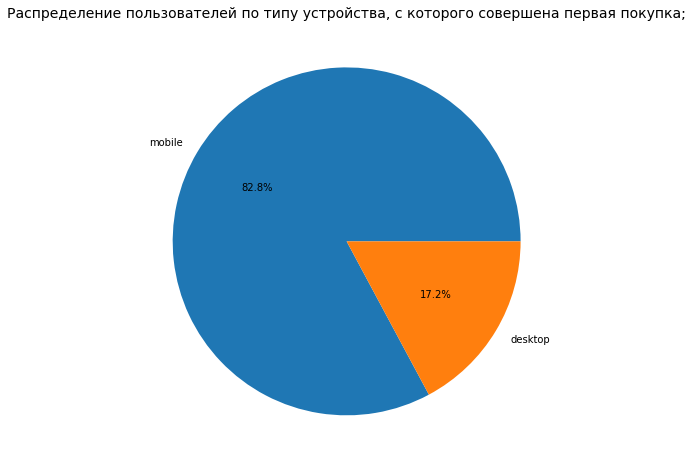

In [44]:
device_type = df_profile_user['device_type_canonical'].value_counts(normalize=True)
labels = device_type.index.tolist()
size = device_type.values.tolist()
plt.figure(figsize=(8, 8))
plt.pie(size,labels=labels,autopct='%1.1f%%' )
plt.title('Распределение пользователей по типу устройства, с которого совершена первая покупка;', fontsize=14)
plt.show()

In [45]:
df_profile_user['device_type_canonical'].value_counts()

mobile     18090
desktop     3748
Name: device_type_canonical, dtype: int64

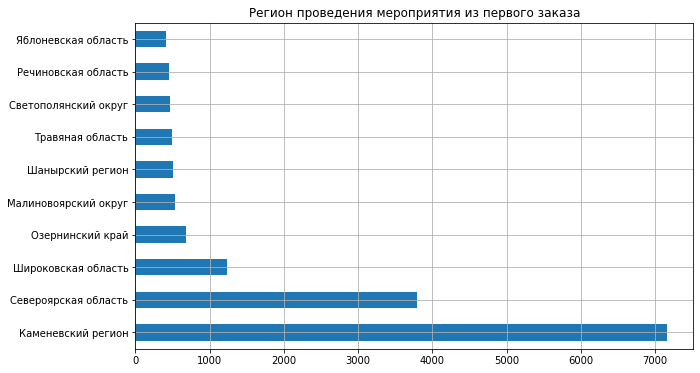

In [46]:
df_profile_user['region_name'].value_counts().head(10).plot(
                    kind='barh',
                    figsize=(10,6),
                    title='Регион проведения мероприятия из первого заказа',
                    rot=0)
plt.grid()
plt.show()

In [47]:
df_profile_user['region_name'].value_counts().head(10)

Каменевский регион      7160
Североярская область    3800
Широковская область     1236
Озернинский край         678
Малиновоярский округ     530
Шанырский регион         505
Травяная область         493
Светополянский округ     464
Речиновская область      446
Яблоневская область      416
Name: region_name, dtype: int64

In [48]:
round(df_profile_user['region_name'].value_counts(normalize=True)*100,2).head(10)

Каменевский регион      32.79
Североярская область    17.40
Широковская область      5.66
Озернинский край         3.10
Малиновоярский округ     2.43
Шанырский регион         2.31
Травяная область         2.26
Светополянский округ     2.12
Речиновская область      2.04
Яблоневская область      1.90
Name: region_name, dtype: float64

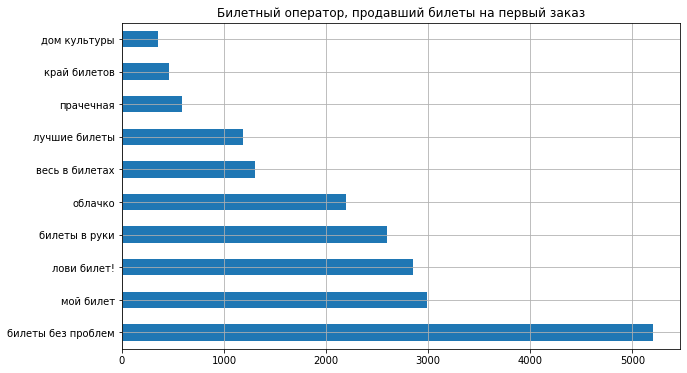

In [49]:
df_profile_user['service_name'].value_counts().head(10).plot(
                    kind='barh',
                    figsize=(10,6),
                    title='Билетный оператор, продавший билеты на первый заказ',
                    rot=0)
plt.grid()
plt.show()

In [50]:
df_profile_user['service_name'].value_counts().head(10)

билеты без проблем    5204
мой билет             2993
лови билет!           2851
билеты в руки         2592
облачко               2194
весь в билетах        1305
лучшие билеты         1186
прачечная              588
край билетов           459
дом культуры           358
Name: service_name, dtype: int64

In [51]:
round(df_profile_user['service_name'].value_counts(normalize=True)*100).head(10)

билеты без проблем    24.0
мой билет             14.0
лови билет!           13.0
билеты в руки         12.0
облачко               10.0
весь в билетах         6.0
лучшие билеты          5.0
прачечная              3.0
край билетов           2.0
дом культуры           2.0
Name: service_name, dtype: float64

Количество пользователей:

По типу их первого мероприятия  

    концерты  9647    44.18 %  
    другое    5465    25.03 %  
    театр     4295    19.67 %   
    стендап   1118    5.12  %  
    спорт     801     3.67  %  
    выставки  417     1.91  %  
    ёлки      95      0.44  %  
    
По типу устройства, с которого совершена первая покупка  

    mobile   18090  82.8%  
    desktop  3748   17.2%
    
По региону проведения мероприятия из первого заказа ТОП 10

    Каменевский регион      7160 32.79 %
    Североярская область    3800 17.40 %
    Широковская область     1236 5.66 %
    Озернинский край         678 3.1 %
    Малиновоярский округ     530 2.43 %
    Шанырский регион         505 2.31 %
    Травяная область         493 2.26 %
    Светополянский округ     464 2.12 %
    Речиновская область      446 2.04 %
    Яблоневская область      416 1.9 %
    
По билетному оператору, продавшему билеты на первый заказ ТОП 10

    билеты без проблем    5204 24 %
    мой билет             2993 14 %
    лови билет!           2851 13 %
    билеты в руки         2592 12 %
    облачко               2194 10 %
    весь в билетах        1305 6 %
    лучшие билеты         1186 5 %
    прачечная              588 3 %
    край билетов           459 2 %
    дом культуры           358 2 %
    
Мы видим преобладают Концерты 44.18 % по типу мироприятия ,большинство 82.8% заказов сделано с мобильных ,
в Каменевский регион 32.79% и 24% пользователей оформляли заказ у оператора "билеты без проблем"

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Отбираем пользователей сделавших 2 и более заказа

In [52]:
df_total_orders_2 = df_profile_user[df_profile_user['total_orders'] >= 2 ].copy()

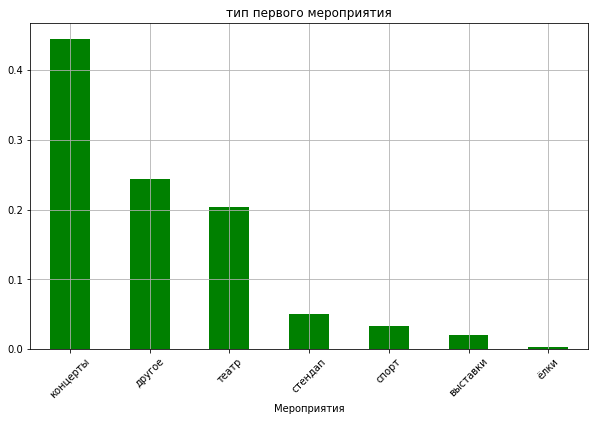

In [53]:
df_total_orders_2['event_type_main'].value_counts(normalize=True).plot(
                    kind='bar',
                    figsize=(10,6),
                    title='тип первого мероприятия',
                    xlabel='Мероприятия',
                    rot=45,
                    color='green')
plt.grid()
plt.show()

In [54]:
round(df_total_orders_2['event_type_main'].value_counts(normalize=True)*100,2)

концерты    44.49
другое      24.35
театр       20.36
стендап      5.08
спорт        3.34
выставки     2.00
ёлки         0.39
Name: event_type_main, dtype: float64

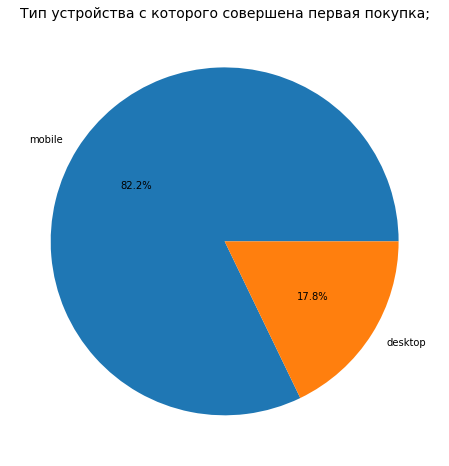

In [55]:
device_type_2 = df_total_orders_2['device_type_canonical'].value_counts(normalize=True)
labels = device_type_2.index.tolist()
size = device_type_2.values.tolist()
plt.figure(figsize=(8, 8))
plt.pie(size,labels=labels,autopct='%1.1f%%' )
plt.title('Тип устройства с которого совершена первая покупка;', fontsize=14)
plt.show()

In [56]:
(df_total_orders_2['device_type_canonical'].value_counts(normalize=True)*100).round(2)

mobile     82.16
desktop    17.84
Name: device_type_canonical, dtype: float64

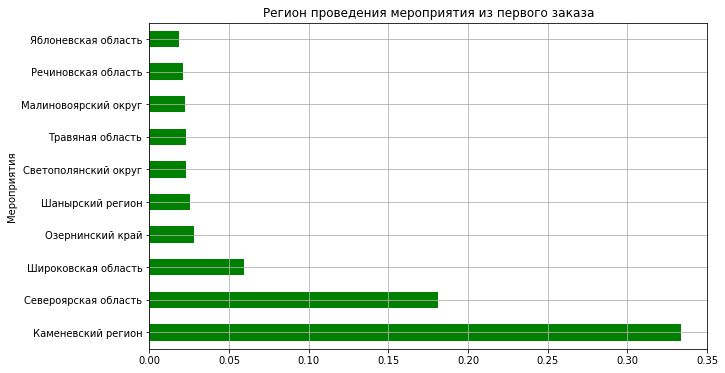

In [57]:
df_total_orders_2['region_name'].value_counts(normalize=True).head(10).plot(
                    kind='barh',
                    figsize=(10,6),
                    title='Регион проведения мероприятия из первого заказа',
                    xlabel='Мероприятия',
                    rot=0,
                    color='green')
plt.grid()
plt.show()

In [58]:
round(df_total_orders_2['region_name'].value_counts(normalize=True)*100,2).head(10)

Каменевский регион      33.36
Североярская область    18.09
Широковская область      5.94
Озернинский край         2.79
Шанырский регион         2.53
Светополянский округ     2.28
Травяная область         2.26
Малиновоярский округ     2.21
Речиновская область      2.12
Яблоневская область      1.85
Name: region_name, dtype: float64

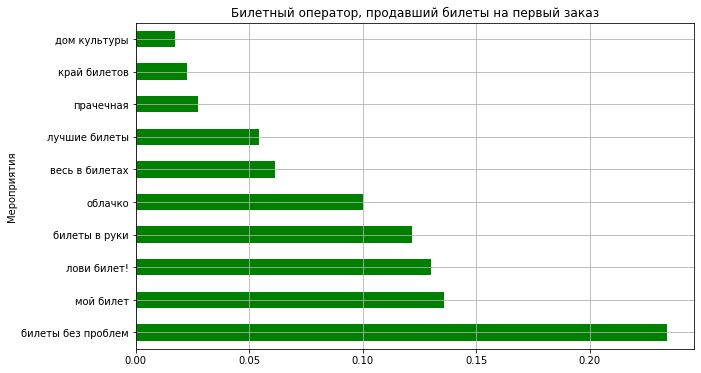

In [59]:
df_total_orders_2['service_name'].value_counts(normalize=True).head(10).plot(
                    kind='barh',
                    figsize=(10,6),
                    title='Билетный оператор, продавший билеты на первый заказ',
                    xlabel='Мероприятия',
                    rot=0,
                    color='green')
plt.grid()
plt.show()

In [60]:
round(df_total_orders_2['service_name'].value_counts(normalize=True)*100,2).head(10)

билеты без проблем    23.41
мой билет             13.59
лови билет!           13.01
билеты в руки         12.17
облачко               10.02
весь в билетах         6.14
лучшие билеты          5.41
прачечная              2.75
край билетов           2.23
дом культуры           1.72
Name: service_name, dtype: float64

Тип первого мероприятия

    концерты    44.49
    другое      24.35
    театр       20.36
    стендап      5.08
    спорт        3.34
    выставки     2.00
    ёлки         0.39
    
Тип устройства, с которого совершена первая покупка

    mobile     82.16
    desktop    17.84
    
Регион проведения мероприятия из первого заказа

    Каменевский регион      33.36
    Североярская область    18.09
    Широковская область      5.94
    Озернинский край         2.79
    Шанырский регион         2.53
    Светополянский округ     2.28
    Травяная область         2.26
    Малиновоярский округ     2.21
    Речиновская область      2.12
    Яблоневская область      1.85

Билетный оператор, продавший билеты на первый заказ

    билеты без проблем    23.41
    мой билет             13.59
    лови билет!           13.01
    билеты в руки         12.17
    облачко               10.02
    весь в билетах         6.14
    лучшие билеты          5.41
    прачечная              2.75
    край билетов           2.23
    дом культуры           1.72
    

В случае с пользователями совершивших 2 и более заказа так же преобладают Концерты 44.49 % по типу мироприятия ,большинство 82.16% заказов сделано с мобильных,в Каменевский регион 33.36% и 23.41% пользователей оформляли заказ у оператора "билеты без проблем" , значимых отличий от основной выборки нет. 



---

**4.1.3.** Гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Количество пользователей совершавших 2 и более закакза, сделавших первый заказ на концерты это 44.49% гараздо выше количества людей посещавших спортивные мероприятия 3.34 %


- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Да,в активных регионах вераятность возврата на платформу гараздо выше чем в остальных (Каменевский регион 33.36% Североярская область 18.09%  в остальных менее 6%) 

---



####  Исследование поведения пользователей через показатели выручки и состава заказа

**4.2.1.** Проследим связь между средней выручкой сервиса с заказа и повторными заказами.

- Построим сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.


Фильтруем пользователей с 1 заказом , пользователи с 2 и болеее заказами датасет был создан ранее .

In [61]:
df_total_orders_1 = df_profile_user[df_profile_user['total_orders'] == 1 ].copy()

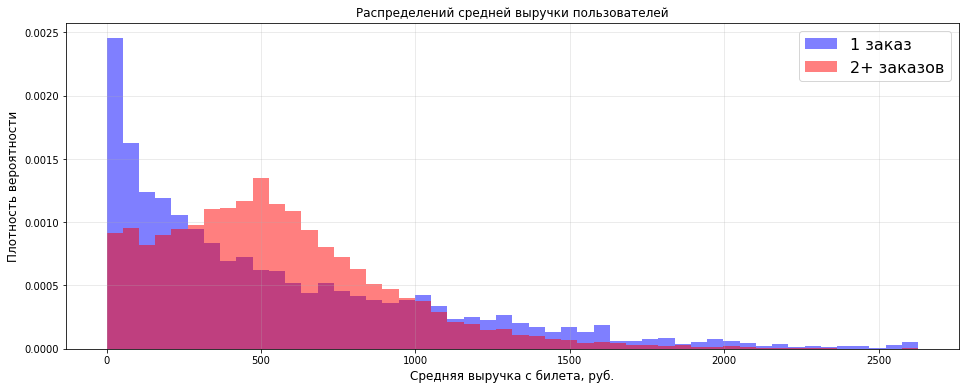

In [62]:
plt.figure(figsize=(16, 6))
plt.hist(df_total_orders_1['avg_revenue_rub'],
         bins=50,
         alpha=0.5,
         label='1 заказ',
         color='blue',
         density=True)
plt.hist(df_total_orders_2['avg_revenue_rub'],
         bins=50,
         alpha=0.5,
         label='2+ заказов',
         color='red',
         density=True)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.title('Распределений средней выручки пользователей')
plt.xlabel('Средняя выручка с билета, руб.', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.show()

Для пользователей с 2 и более заказами распределение значения асимметричное, скошенное вправо.
Максимальное количество пользователи с 2 и более заказами,сконцентрированна в районей 500 р. 
Для пользователей с 1 заказ  гистограмма с правый скосом.
Максимальное количество пользователей с одним заказ начинаеться от нулевых значений с резким спадом и последующим уменьшением.
Высокие значения при нулевой стоимости может говорить о том что сервис мог проводить какую либо акцию где пользователем предостовлял промокоды ,сертификаты т.п.


**4.2.2.** Сравниваем распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.


Саздаем датасет в пользователями 2-4 заказа и 5 и более

In [63]:
df_total_orders_2_4 = df_profile_user[df_profile_user['is_two'] == True].copy()
df_total_orders_5 = df_profile_user[df_profile_user['is_five'] == True].copy()

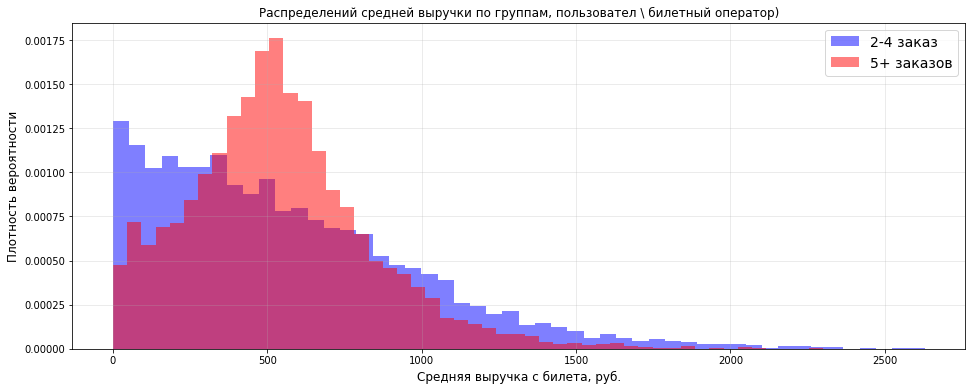

In [64]:
plt.figure(figsize=(16, 6))
plt.hist(df_total_orders_2_4['avg_revenue_rub'],
         bins=50,
         alpha=0.5,
         label='2-4 заказ',
         color='blue',
         density=True)
plt.hist(df_total_orders_5['avg_revenue_rub'],
         bins=50,
         alpha=0.5,
         label='5+ заказов',
         color='red',
         density=True)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.title('Распределений средней выручки по группам, пользовател \ билетный оператор)')
plt.xlabel('Средняя выручка с билета, руб.', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.show()

Для пользователей с 5 и более заказами распределение значения асимметричное, скошенное вправо.
Максимальное количество пользователи с 5 и более заказами,сконцентрированна чуть выше 500 р.
Для пользователей с 2 - 4 и более заказами  гистограмма с правый скосом.
Максимальное количество пользователей с одним заказ начинаеться от нулевых значений с последующим уменьшением.
Высокие значения при нулевой стоимости может говорить о том что сервис мог проводить какую либо акцию,
где пользователем предостовлял промокоды ,сертификаты и пользователи сделали повторные заказы.


**4.2.3.** Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.


In [67]:
def assign_segment(tickets):
    if 1 <= tickets < 2:
        return '1 билет'
    elif 2 <= tickets < 3:
        return '2 билета'
    elif 3 <= tickets < 5:
        return '3–4 билетов'
    else:  
        return '5+ билетов'

df_total_orders_2['segment'] = df_total_orders_2['avg_tickets'].apply(assign_segment).copy()
df_total_orders_2.groupby('segment')['user_id'].count()

segment
1 билет        1235
2 билета       7187
3–4 билетов    4929
5+ билетов      124
Name: user_id, dtype: int64

In [69]:
round(df_total_orders_2.groupby('segment')['user_id'].count() / len(df_total_orders_2['user_id'])*100,2)

segment
1 билет         9.17
2 билета       53.34
3–4 билетов    36.58
5+ билетов      0.92
Name: user_id, dtype: float64

Пользователи совершившие 2 и более заказы в основном покупают

2 билета что состовляет 53.3%   
3-4 билета 36.6%  
1 билет 9.2%    
более 5 билетов 1 %


####  Исследование временных характеристик первого заказа и их влияния на повторные покупки


**4.3.1.** Проанализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

Для каждого дня недели подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.



In [71]:
df_total_orders_2['day']= df_total_orders_2['first_order_date'].dt.dayofweek+1

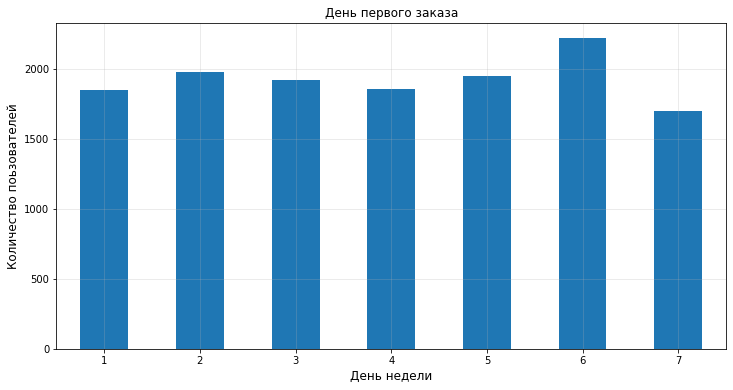

In [72]:
df_total_orders_2.groupby('day')['user_id'].count().plot(figsize=(12, 6),kind='bar',rot=0)
plt.title('День первого заказа')
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Количество поьзователей', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [76]:
df_total_orders_2.groupby('day')['user_id'].count()

day
1    1851
2    1978
3    1921
4    1857
5    1948
6    2219
7    1701
Name: user_id, dtype: int64

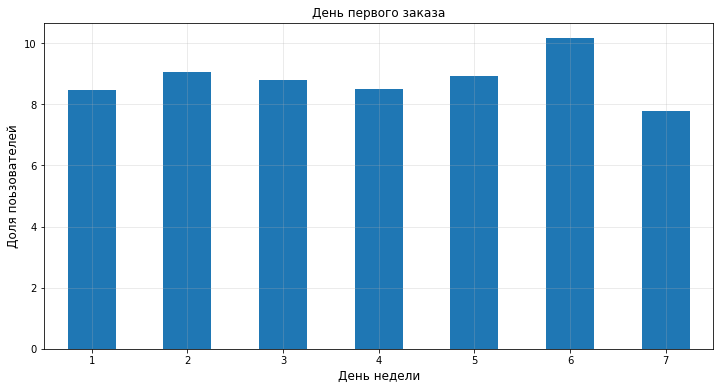

In [77]:
round(df_total_orders_2.groupby('day')['user_id'].count() / len(df_profile_user['user_id'])*100,2).plot(figsize=(12, 6),kind='bar',rot=0)
plt.title('День первого заказа')
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Доля поьзователей', fontsize=12)
plt.grid(True, alpha=0.3)

In [78]:
round(df_total_orders_2.groupby('day')['user_id'].count() / len(df_profile_user['user_id'])*100,2)

day
1     8.48
2     9.06
3     8.80
4     8.50
5     8.92
6    10.16
7     7.79
Name: user_id, dtype: float64

2219 клиетов ,с заказами более 2 , сделали первый заказ в субботу это 10.16% , в минимальное 1701 в воскресенье  7.8%

---

**4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [79]:
round(df_total_orders_2_4['avg_days'].mean())

19

In [80]:
round(df_total_orders_5['avg_days'].mean())

9

Среднее время между заказами у пользоватилей с 2-4 заками состовляет 19 дней 
Среднее время между заказами у пользоватилей с 5 и более заками состовляет 9 дней эти пользователи делают заказы гараздо чаще.



####  Корреляционный анализ количества покупок и признаков пользователя

**4.4.1:** Проведем корреляционный анализ:


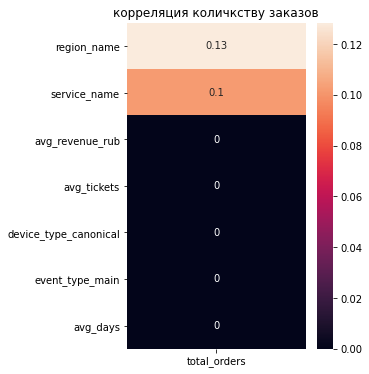

In [81]:
interval_cols = ['total_orders','avg_revenue_rub', 'avg_tickets','avg_days']
correlation_matrix = df_profile_user[['total_orders','avg_revenue_rub', 'avg_tickets', 'device_type_canonical', 'region_name', 'service_name',
                         'event_type_main','avg_days']].phik_matrix(interval_cols=interval_cols)
corr_matrix = correlation_matrix.loc[correlation_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)
plt.figure(figsize=(4,6))
sns.heatmap(data=corr_matrix,annot=True)
plt.title('корреляция количеству заказов')
plt.show()

При рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов результаты 
оказались близки к 0.т.к. в `total_orders` преобладает одно значение. Выделим сегменты пользователей
- 1 заказ;
- от 2 до 4 заказов;
- от 5 и выше

interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets', 'avg_days']


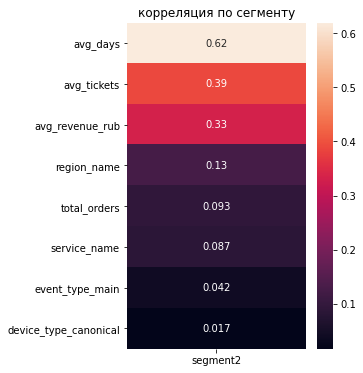

In [93]:
def assign_segment(orders):
    if  orders == 1:
        return '1 заказ'
    elif orders <= 4:
        return '2-4 заказа'
    else:  
        return '5+ заказа'

df_profile_user['segment2'] = df_profile_user['total_orders'].apply(assign_segment)

correlation_matrix_segment = df_profile_user[['total_orders','segment2','avg_revenue_rub', 'avg_tickets', 'device_type_canonical', 'region_name', 'service_name',
                         'event_type_main','avg_days']].phik_matrix()
corr_matrix_segment = correlation_matrix_segment.loc[correlation_matrix_segment.index != 'segment2'][['segment2']].sort_values(by='segment2', ascending=False)
plt.figure(figsize=(4,6))
sns.heatmap(data=corr_matrix_segment,annot=True)
plt.title('корреляция по сегменту')
plt.show()


Умеренно положительная корреляции по количеству заказов просматриваеться по столбцам  
avg_days 0.62   
avg_tickets 0.39   
avg_revenue_rub 0.33

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**1.Загрузка данных** 

Данные были взяты из data-analyst-afisha и сформированы и выгружены с помощью SQL запроса.
В данных содержиться 290611 строка и 15 столбцов , пропуски в days_since_prev. Типы данных корректны.  

**2.Предобрботка данных** 

В данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведем выручку к единой валюте — российскому рублю.Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — final_tickets_tenge_df.csv.Значения в рублях представлено для 100 тенге.Результаты преобразования сохраним в новый столбец revenue_rub.  

Мнянем тип данных data datetime64 для коректного объеденения ,делим курс на 100 т.к. в данных используеться курс для 100 тенге, оставляем датасет normal_curs,data,cdx столбцы и обьеденяем с основным и создаем новый df_marge . Далее перемножаем normal_cursна revenue и создаем столбец revenue_rub c выручкой от заказа в рублях.  

Проверли уникальные значения в `device_type_canonical`,`service_name`,`event_type_main`,`region_name`,`city_name`.
Проверели отсутствие  дубликатов.  
В столбце revenue_rub присутствуют анаомално высокие значения и отрицательные .Стандартное отклонение 875,5 превышает среднее значение 555,6. Это признак высокой вариативности — данные распределены неравномерно. Отфильтруем данные по 1 и 99 перцентилю этого будет достаточно чтобы отбросить отрицательные значения и анаомално высокие значения. Суммы заказов с нулевыми значениями оставим т.к. могли использовать промокоды, скидкки,акции и сертификаты.
В столбце tickets_count присутствуют анаомално высокие значения. Медиана 3 близка к среднему 2,75, что указывает на относительно симметричное распределение данных в центральной части. Отфильтруем данные по 99 перцентилю этого будет достаточно чтобы отбросить анаомално высокие значения
После фильтрации создаем новый df_filter в котором содержиться 287 405 строк,что на 3 206 (около 1 %) меньше исходных данных.

**3.Создние профиля пользователя**

Создаем модели для прогнозирования возврата пользователей на основе агрегированных признаков, описывающие поведение и профиль каждого пользователя.

дату первого и последнего заказа;
устройство, с которого был сделан первый заказ;
регион, в котором был сделан первый заказ;
билетного партнёра, к которому обращались при первом заказе;
жанр первого посещённого мероприятия (используем поле event_type_main);
общее количество заказов;
средняя выручка с одного заказа в рублях;
среднее количество билетов в заказе;
среднее время между заказами.
Создаем два бинарных признака:

is_two — совершил ли пользователь 2 и более заказа; is_five — совершил ли пользователь 5 и более заказов.

Объеденяем все в один датасет profile_user и нормализуеи данные. В итоге в данных 21838 пользователь.

**4.Исследовательский анализ**

4.1  

Количество пользвателей преобладает Концерты 44.18 % по типу мироприятия ,большинство 82.8% заказов сделано с мобильных ,
в Каменевский регион 32.79% и 24% пользователей оформляли заказ у оператора "билеты без проблем"  

В случае с пользователями совершивших 2 и более заказа так же преобладают Концерты 44.49 % по типу мироприятия ,большинство 82.16% заказов сделано с мобильных,в Каменевский регион 33.36% и 23.41% пользователей оформляли заказ у оператора "билеты без проблем" , значимых отличий от основной выборки нет.  

Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
Количество пользователей совершавших 2 и более закакза, сделавших первый заказ на концерты это 44.49% гараздо выше количества людей посещавших спортивные мероприятия 3.34 %

Гипотеза 2. В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.
Да,в активных регионах вераятность возврата на платформу гараздо выше чем в остальных (Каменевский регион 33.36% Североярская область 18.09% в остальных менее 6%)  

4.2  

Для пользователей с 2 и более заказами распределение значения асимметричное, скошенное вправо. Максимальное количество пользователи с 2 и более заказами,сконцентрированна в районей 500 р. Для пользователей с 1 заказ гистограмма с правый скосом. Максимальное количество пользователей с одним заказ начинаеться от нулевых значений с резким спадом и последующим уменьшением. Высокие значения при нулевой стоимости может говорить о том что сервис мог проводить какую либо акцию где пользователем предостовлял промокоды ,сертификаты т.п.  

Для пользователей с 5 и более заказами распределение значения асимметричное, скошенное вправо.
Максимальное количество пользователи с 5 и более заказами,сконцентрированна чуть выше 500 р.
Для пользователей с 2 - 4 и более заказами  гистограмма с правый скосом.
Максимальное количество пользователей с одним заказ начинаеться от нулевых значений с последующим уменьшением.
Высокие значения при нулевой стоимости может говорить о том что сервис мог проводить какую либо акцию,
где пользователем предостовлял промокоды ,сертификаты и пользователи сделали повторные заказы.

Пользователи совершившие 2 и более заказы в основном покупают

2 билета что состовляет 53.3%   
3-4 билета 36.6%  
1 билет 9.2%    
более 5 билетов 1 %  

4.3  

2219 клиетов ,с заказами более 2 , сделали первый заказ в субботу это 10.16% , в минимальное 1701 в воскресенье  7.8%  

Среднее время между заказами у пользоватилей с 2-4 заками состовляет 19 дней Среднее время между заказами у пользоватилей с 5 и более заками состовляет 9 дней эти пользователи делают заказы гараздо чаще.  

4.4  

При рассчитайте коэффициент корреляции phi_k между признаками профиля пользователя и числом заказов результаты оказались близки к 0.т.к. в total_orders преобладает одно значение. Выделим сегменты пользователей  
- 1 заказ;
- от 2 до 4 заказов;
- от 5 и выше

Умеренно положительная корреляции по количеству заказов просматриваеться по столбцам  
avg_days 0.62   
avg_tickets 0.39   
avg_revenue_rub 0.33

**5.Общий вывод**
Наибольшее количество клиентов сделавших 2 и более заказа находиться в Каменевский регион и Североярская область ,клиенты в основном делают заказы с мобильного устройства,предпочитаю  концерты , большинство заказов было сделано через оператора "билеты без проблем".В 53 % случаев покупают 2 билета на мироприятие. Средний чек состовляет ориентировочно 500 р.В большенстве слачаев 
клиенты оформляют певый заказ с субботу.

Для пользователей сделавших 1 заказ предложить скидку на 2 заказ.Сделать рассылку с афишами концертов.В менее активных регионах 
проанализируйте причины низкой активности ,запустите программы лояльности.


### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**